<a href="https://colab.research.google.com/github/ricardocasallas3-ux/mesa-servicio-ia/blob/main/mvp_datos_reales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MVP sobre datos reales (anonimizados) — Mesa de servicio

Carga `incidentes_anonimizado.db` desde Google Drive, hace el análisis (EDA + sentimiento + frustración + categorías) y genera `resultados.json`.

Al final tienes **dos rutas**: (A) descargar el JSON, o (B) **publicarlo directo al dashboard** desde Colab.

Ejecuta *Entorno de ejecución → Ejecutar todo*.

## 1. Conectar Drive y localizar la base

In [10]:
from google.colab import drive
drive.mount('/content/drive')

import glob, os
FILE_ID = '1FZhxpcYeKsriLIHpKSJlfZNjygXZXqmX'
cands = glob.glob('/content/drive/MyDrive/**/incidentes_anonimizado.db', recursive=True)
for c in cands:
    print(round(os.path.getsize(c)/1e6, 1), 'MB ->', c)
if cands:
    RUTA_DB = max(cands, key=os.path.getsize)   # elige el mas grande = el real
    print('USANDO:', RUTA_DB)
else:
    import gdown; RUTA_DB = '/content/incidentes_anonimizado.db'
    gdown.download(id=FILE_ID, output=RUTA_DB, quiet=False)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
0.0 MB -> /content/drive/MyDrive/incidentes_anonimizado.db
84.6 MB -> /content/drive/MyDrive/Especializacion IA/incidentes_anonimizado.db
USANDO: /content/drive/MyDrive/Especializacion IA/incidentes_anonimizado.db


## 2. Cargar los datos
Lista las tablas y elige la de texto. Por defecto usa la primera con columna `resumen`; si prefieres otra (p. ej. `issues`), cambia `TABLA_FORZADA`.

In [11]:
import sqlite3, pandas as pd, numpy as np, re, json, os
con = sqlite3.connect(RUTA_DB)

tablas = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table'", con)['name'].tolist()
print('Tablas:', tablas)

TABLA_FORZADA = None   # <-- pon aqui 'issues' u otra si quieres forzarla
TABLA = TABLA_FORZADA
if not TABLA:
    for t in tablas:
        cols = pd.read_sql('SELECT * FROM "%s" LIMIT 1' % t, con).columns.str.lower().tolist()
        if 'resumen' in cols:
            TABLA = t; break
TABLA = TABLA or (tablas[0] if tablas else None)
print('Tabla usada:', TABLA)

df = pd.read_sql('SELECT * FROM "%s"' % TABLA, con)
df.columns = df.columns.str.lower()
print('Filas, columnas:', df.shape)
print('Columnas:', df.columns.tolist())
df.head()

Tablas: ['sync_log', 'correcciones_clasificacion', 'ingresadas', 'reglas_bti', 'mci3_bti', 'mci3_evolucion', 'bti_maestro', 'ordenes_diarias', 'issues', 'comments', 'mci3_priorizacion', 'clasificaciones']
Tabla usada: issues
Filas, columnas: (21526, 31)
Columnas: ['id', 'proyecto', 'tipo de incidencia', 'clave', 'resumen', 'país', 'canal', 'marcas - comerciales ixc', 'creador', 'persona asignada', 'prioridad', 'impacto', 'urgencia', 'estado', 'creada', 'actualizada', 'resuelta', 'cantidad de ordenes', 'resolución', 'tipo de canal', 'descripción', 'ixcomercio incidentes', 'incidencias enlazadas', 'tiempo para iniciar', 'tiempo para resolver', 'status transition.authoremail', 'request type', 'comentario', 'responsable nivel 1', 'ordenes extraidas', 'extracted_at']


,id,proyecto,tipo de incidencia,clave,resumen,país,canal,marcas - comerciales ixc,creador,persona asignada,...,ixcomercio incidentes,incidencias enlazadas,tiempo para iniciar,tiempo para resolver,status transition.authoremail,request type,comentario,responsable nivel 1,ordenes extraidas,extracted_at
0,366290,IT Helpdesk - IXComercio,Incidente,ITHD-94869,Error en la OT de la orden R_36657-CLIENTE_02_...,Colombia,Tienda Física,CLIENTE_02,[OCULTO],Juan Pinzon,...,Canal Tiendas Físicas,None,1 m,None,None,IXComercio Incidentes,None,[OCULTO],None,2026-06-16T19:07:44.049162
1,366240,IT Service Desk,Incidente ITSD,ITSD-82393,ERROR EN CALIFICACIÓN DE NUEVO LEAD // IDENTIF...,None,None,None,[OCULTO],Brayan Camilo Delgado,...,None,None,None,None,None,Incidentes Aplicaciones,[Brian Flores Gonzales | 2026-06-16]: \n---\n[...,[OCULTO],None,2026-06-16T19:07:44.049417
2,366285,IT Service Desk,Solicitud ITSD,ITSD-82413,Solicitud de Licencia Claude IA,None,None,None,[OCULTO],Juan Perez,...,None,None,None,None,None,Solicitud Aplicaciones,[Jira Sync | 2026-06-16]: Este ticket será ate...,[OCULTO],None,2026-06-16T19:07:44.049549
3,366284,IT Service Desk,Solicitud ITSD,ITSD-82412,Crear RW de WD,None,None,None,[OCULTO],Cristina Miranda,...,None,None,None,None,None,Solicitud Aplicaciones,[Harismery Garcia | 2026-06-16]: \n---\n[Crist...,[OCULTO],ID_ff1095a960,2026-06-16T19:07:44.049754
4,366248,IT Service Desk,Incidente ITSD,ITSD-82397,Habilitar usuario y generar nuevo link de acti...,None,None,None,[OCULTO],Oscar Ortiz,...,None,None,None,None,None,Incidente Accesos,[Oscar Ortiz | 2026-06-16]: Buen día estimado ...,[OCULTO],ID_c7d8f32466,2026-06-16T19:07:44.049983


## 3. Limpieza básica

In [12]:
# Detecta columna de texto y de etiqueta (ajusta si tu tabla usa otros nombres)
posibles_texto = ['resumen', 'summary', 'descripcion', 'description', 'texto', 'comentario']
COL_TEXTO = next((c for c in posibles_texto if c in df.columns), None) or df.select_dtypes('object').columns[0]
posibles_label = ['clasificacion', 'categoria', 'tipo', 'estado', 'label']
COL_LABEL = next((c for c in posibles_label if c in df.columns), None)

df = df.drop_duplicates()
df[COL_TEXTO] = df[COL_TEXTO].astype(str).str.strip()
print('Texto:', COL_TEXTO, '| Etiqueta:', COL_LABEL)
print('Tras limpieza:', df.shape)

Texto: resumen | Etiqueta: estado
Tras limpieza: (21526, 31)


## 4. Análisis exploratorio (categorías)

,count
estado,
Cerrado,18071
Finalizada,1690
Resuelto,405
Nuevo,242
Terminado,230
En Nivel 1,206
Tareas por hacer,175
Pendiente de proveedor,164
CANCELED,46


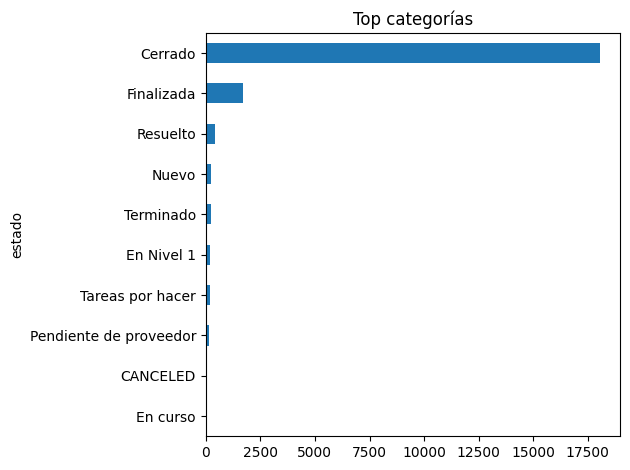

In [13]:
import matplotlib.pyplot as plt
if COL_LABEL:
    top = df[COL_LABEL].value_counts().head(10)
    display(top)
    top[::-1].plot(kind='barh'); plt.title('Top categorías'); plt.tight_layout(); plt.show()

## 5. Sentimiento y nivel de frustración
Léxico simple en español adaptado a tickets técnicos (MVP).

,sentimiento,frustracion
count,21526.000000,21526.000000
mean,-0.302440,65.122001
std,0.466374,23.318700
min,-1.000000,0.000000
25%,-1.000000,50.000000
50%,0.000000,50.000000
75%,0.000000,100.000000
max,1.000000,100.000000


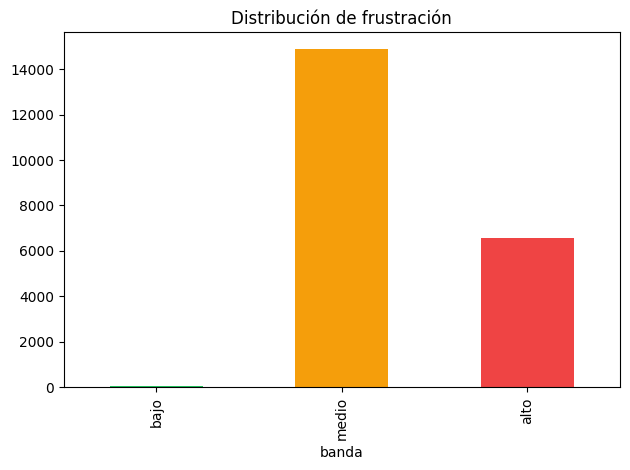

In [14]:
POS = set('gracias ok correcto solucionado resuelto disponible exitoso'.split())
NEG = set('error falla fallo sin no cancelacion cancelación pendiente caido caída bloqueo rechazo duplicado incidencia problema demora retraso urgente'.split())

def sent(t):
    palabras = re.findall(r'[a-záéíóúñ]+', str(t).lower())
    p = sum(w in POS for w in palabras); n = sum(w in NEG for w in palabras)
    return round((p - n) / (p + n), 3) if (p + n) else 0.0

df['sentimiento'] = df[COL_TEXTO].apply(sent)
df['frustracion'] = ((1 - df['sentimiento']) / 2 * 100).round(1)
df['banda'] = df['frustracion'].apply(lambda f: 'alto' if f >= 66 else ('medio' if f >= 40 else 'bajo'))
display(df[['sentimiento','frustracion']].describe())
df['banda'].value_counts().reindex(['bajo','medio','alto']).plot(kind='bar', color=['#22c55e','#f59e0b','#ef4444'])
plt.title('Distribución de frustración'); plt.tight_layout(); plt.show()

## 6. Generar `resultados.json`

In [15]:
from datetime import datetime

bins = [-1, -0.6, -0.2, 0.2, 0.6, 1.0001]
etq = ['muy negativo','negativo','neutro','positivo','muy positivo']
hist = pd.cut(df['sentimiento'], bins=bins, labels=etq, include_lowest=True).value_counts().reindex(etq).fillna(0).astype(int)

top_cat = df[COL_LABEL].value_counts().head(8).to_dict() if COL_LABEL else {}

alta = df[df['banda'] == 'alto']
if COL_LABEL and len(alta):
    imp = alta[COL_LABEL].value_counts(normalize=True).head(6)
    impulsores = [{'variable': str(k)[:40], 'importancia': round(float(v), 3)} for k, v in imp.items()]
else:
    impulsores = []

id_col = 'orden_id' if 'orden_id' in df.columns else df.columns[0]
def recom(f):
    return 'Contacto inmediato y plan de retencion' if f >= 66 else ('Seguimiento proactivo' if f >= 40 else 'Monitoreo estandar')
altos = df.sort_values('frustracion', ascending=False).head(15)
tickets = [{
    'id': str(r[id_col])[:20], 'cliente': str(r[id_col])[:20],
    'clasificacion': (str(r[COL_LABEL])[:40] if COL_LABEL else ''),
    'frustracion': float(r['frustracion']), 'riesgo': float(r['frustracion']),
    'recomendacion': recom(r['frustracion'])
} for _, r in altos.iterrows()]

resultados = {
    'generado': datetime.now().strftime('%Y-%m-%d %H:%M') + ' (datos reales anonimizados)',
    'kpis': {
        'total_tickets': int(len(df)),
        'phishing_aislados': 0,
        'procesados': int(len(df)),
        'pct_alto_riesgo': round(float((df['banda']=='alto').mean()*100), 1),
        'frustracion_promedio': round(float(df['frustracion'].mean()), 1),
        'sentimiento_promedio': round(float(df['sentimiento'].mean()), 3)
    },
    'clasificacion': {str(k)[:40]: int(v) for k, v in top_cat.items()},
    'distribucion_riesgo': {k: int(v) for k, v in df['banda'].value_counts().reindex(['bajo','medio','alto']).fillna(0).astype(int).items()},
    'sentimiento_hist': {'bins': etq, 'conteo': hist.tolist()},
    'impulsores': impulsores,
    'tickets_alto_riesgo': tickets
}

with open('resultados.json', 'w', encoding='utf-8') as f:
    json.dump(resultados, f, ensure_ascii=False, indent=2)
print('Generado resultados.json')
print(json.dumps(resultados['kpis'], indent=2, ensure_ascii=False))

Generado resultados.json
{
  "total_tickets": 21526,
  "phishing_aislados": 0,
  "procesados": 21526,
  "pct_alto_riesgo": 30.6,
  "frustracion_promedio": 65.1,
  "sentimiento_promedio": -0.302
}


## RUTA A — Descargar `resultados.json`
Si prefieres subirlo tú a mano al repo (`docs/data/resultados.json`).

In [16]:
try:
    from google.colab import files
    files.download('resultados.json')
except Exception as e:
    print('Descarga manual del archivo resultados.json. Detalle:', e)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## RUTA B — Publicar directo al dashboard (GitHub API)
Actualiza `docs/data/resultados.json` en el repo **sin subir nada a mano**; el dashboard de GitHub Pages se refresca en ~1 minuto.

**Necesitas un token de GitHub (una sola vez):**
1. GitHub → tu foto (arriba der.) → **Settings** → abajo **Developer settings**.
2. **Personal access tokens → Fine-grained tokens → Generate new token**.
3. *Repository access:* **Only select repositories** → `mesa-servicio-ia`.
4. *Permissions → Repository permissions → Contents:* **Read and write**.
5. **Generate token** y copia el valor (empieza por `github_pat_`).

Al ejecutar la celda te pedirá pegarlo (no se muestra ni se guarda en el notebook).

In [17]:
import base64, requests, getpass

GH_OWNER  = 'ricardocasallas3-ux'
GH_REPO   = 'mesa-servicio-ia'
GH_PATH   = 'docs/data/resultados.json'
GH_BRANCH = 'main'

token = getpass.getpass('Pega tu token de GitHub (no se mostrara): ')
headers = {'Authorization': 'token ' + token, 'Accept': 'application/vnd.github+json'}
url = 'https://api.github.com/repos/%s/%s/contents/%s' % (GH_OWNER, GH_REPO, GH_PATH)

# sha del archivo actual (si existe) para poder reemplazarlo
r = requests.get(url, headers=headers, params={'ref': GH_BRANCH})
sha = r.json().get('sha') if r.status_code == 200 else None

with open('resultados.json', 'rb') as f:
    contenido = base64.b64encode(f.read()).decode()

payload = {'message': 'Actualizar dashboard desde Colab', 'content': contenido, 'branch': GH_BRANCH}
if sha:
    payload['sha'] = sha

resp = requests.put(url, headers=headers, json=payload)
if resp.status_code in (200, 201):
    print('OK: dashboard actualizado. Mira en ~1 min:')
    print('https://%s.github.io/%s/' % (GH_OWNER, GH_REPO))
else:
    print('Error %s:' % resp.status_code, resp.json())

Pega tu token de GitHub (no se mostrara): ··········
OK: dashboard actualizado. Mira en ~1 min:
https://ricardocasallas3-ux.github.io/mesa-servicio-ia/
